In [2]:

import os
import re
import subprocess
import tempfile

import numpy as np
import pandas as pd
import librosa
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
tqdm.pandas()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight  # optional: for explicit weights


In [3]:
import os

i = 0
dataset_path = r"E:\445 project\speech_recognization_systems-group-6\Speech_Dataset"

for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        x = os.path.join(dirname, filename)
        if x.endswith('.mp3'):
            # print(filename.split('.')[0], end=' ')
            i += 1

print(f'Number of Audio files: {i}')


Number of Audio files: 2138


In [4]:
path = r"E:\445 project\speech_recognization_systems-group-6\Speech_Dataset\recordings\recordings"
audiofiles = os.listdir(path)

df = pd.DataFrame()
df['audiofiles'] = audiofiles

df['labels'] = [re.sub(r'\d+\.mp3$', '', audio) for audio in tqdm(audiofiles)]

df.head()

100%|██████████| 2138/2138 [00:00<00:00, 1226565.72it/s]


,audiofiles,labels
0,afrikaans1.mp3,afrikaans
1,afrikaans2.mp3,afrikaans
2,afrikaans3.mp3,afrikaans
3,afrikaans4.mp3,afrikaans
4,afrikaans5.mp3,afrikaans


In [5]:
print(df.labels.value_counts().index.to_list())

['english', 'spanish', 'arabic', 'mandarin', 'french', 'korean', 'portuguese', 'russian', 'dutch', 'turkish', 'german', 'polish', 'italian', 'japanese', 'macedonian', 'cantonese', 'farsi', 'vietnamese', 'swedish', 'romanian', 'amharic', 'hindi', 'serbian', 'bulgarian', 'tagalog', 'bengali', 'urdu', 'greek', 'thai', 'nepali', 'ukrainian', 'miskito', 'kurdish', 'punjabi', 'pashto', 'bosnian', 'hungarian', 'albanian', 'gujarati', 'hebrew', 'kiswahili', 'czech', 'hausa', 'mongolian', 'indonesian', 'tigrigna', 'taiwanese', 'danish', 'armenian', 'croatian', 'finnish', 'khmer', 'krio', 'lithuanian', 'norwegian', 'ga', 'tamil', 'somali', 'wolof', 'georgian', 'malay', 'bambara', 'dari', 'afrikaans', 'yiddish', 'yoruba', 'twi', 'slovak', 'catalan', 'estonian', 'kikuyu', 'vlaams', 'uzbek', 'synthesized', 'malayalam', 'xiang', 'igbo', 'tajiki', 'azerbaijani', 'belarusan', 'ibibio', 'fijian', 'tibetan', 'latvian', 'oromo', 'fanti', 'pulaar', 'uyghur', 'kambaata', 'kazakh', 'icelandic', 'lao', 'mara

In [6]:
import numpy as np
from tqdm.auto import tqdm  # For progress_apply

# Expanded lists with common accent variants from dataset
english = [
    'english', 'us', 'uk', 'new-zealand', 'indian-english',
    'england', 'scotland', 'ireland', 'wales', 'canadian'
]

south_asian = [
    'hindi', 'urdu', 'bengali', 'nepali', 'punjabi', 'gujarati', 'tamil',
    'telugu', 'oriya', 'marathi', 'malayalam', 'sinhala', 'konkani',
    'kannada', 'sindhi', 'hindko', 'indian', 'sri-lankan'
]

east_se_asian = [
    'mandarin', 'cantonese', 'japanese', 'korean', 'vietnamese',
    'thai', 'filipino', 'tagalog', 'indonesian', 'burmese', 'khmer',
    'malay', 'lao', 'hainanese', 'xiang', 'wu', 'gan', 'hakka',
    'teochew', 'shan', 'mizo', 'taiwanese', 'chinese'
]

middle_eastern_central_asian = [
    'farsi', 'turkish', 'hebrew', 'kurdish', 'pashto', 'tajiki',
    'kazakh', 'uzbek', 'turkmen', 'azerbaijani', 'dari', 'arabic',
    'uyghur', 'tatar', 'greek', 'armenian', 'georgian', 'persian'
]

african = [
    'amharic', 'swahili', 'somali', 'yoruba', 'zulu', 'hausa', 'igbo',
    'afrikaans', 'rwanda', 'shona', 'bambara', 'tigrigna', 'moore',
    'kikongo', 'pulaar', 'susu', 'akan', 'lusoga', 'tswana', 'bamun',
    'sara', 'wolof', 'nuer', 'dinka', 'bari', 'mandinka', 'ibibio',
    'kru', 'garifuna', 'kambaata', 'namibian', 'nandi', 'luo', 'xasonga',
    'gedeo', 'fang', 'ashanti', 'serer', 'kikuyu', 'bafang', 'hadiyya',
    'south-african'
]

oceanian = [
    'fijian', 'pohnpeian', 'chamorro', 'carolinian', 'yapese', 'rotuman',
    'bai', 'lamotrekese', 'mortlockese', 'satawalese', 'cebuano',
    'australian'  # Already in english, but flag if overlap
]

western_european = [
    'french', 'german', 'dutch', 'portuguese', 'spanish', 'italian', 'sicilian', 'catalan',
    'irish', 'faroese', 'frisian', 'vlaams', 'luxembourgeois', 'maltese', 'basque', 'sardinian', 'bavarian',
    'brazilian', 'brazilian-portuguese', 'france'
]

northern_european = [
    'swedish', 'danish', 'norwegian', 'finnish', 'icelandic', 'estonian'
]

eastern_european = [
    'russian', 'polish', 'czech', 'slovak', 'ukrainian', 'belarusan', 'bulgarian',
    'romanian', 'serbian', 'croatian', 'bosnian', 'slovenian', 'macedonian', 'albanian',
    'hungarian'
]

all_lists = [english, south_asian, east_se_asian, middle_eastern_central_asian, african, oceanian, western_european, northern_european, eastern_european]

# Check for overlaps across lists
overlap_set = set()
duplicates = []
for l in all_lists:
    for x in l:
        if x in overlap_set:
            duplicates.append(x)
        overlap_set.add(x)
if duplicates:
    print("Overlaps found:", duplicates)
else:
    print("No overlaps detected.")

def get_general_label(x):
    if x in english:
        return 'English'
    elif x in south_asian:
        return 'South Asian'
    elif x in east_se_asian:
        return 'East Asian or South East Asian'
    elif x in middle_eastern_central_asian:
        return 'Middle Eastern, Central Asian or Southern Europe'
    elif x in african:
        return 'African'
    elif x in oceanian:
        return 'Oceanian or Other'  # Explicit check
    elif x in western_european:
        return 'Western European'
    elif x in northern_european:
        return 'Northern European'
    elif x in eastern_european:
        return 'Eastern European'
    return 'Oceanian or Other'

df['generallabel'] = df['labels'].progress_apply(get_general_label)
print(df['generallabel'].value_counts()) 


e:\445 project\speech_recognization_systems-group-6\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


No overlaps detected.


100%|██████████| 2138/2138 [00:00<00:00, 852659.69it/s]

generallabel
English                                             579
Western European                                    409
East Asian or South East Asian                      268
Middle Eastern, Central Asian or Southern Europe    242
Eastern European                                    229
Oceanian or Other                                   145
African                                             112
South Asian                                         105
Northern European                                    49
Name: count, dtype: int64


In [7]:
df.generallabel.value_counts()

generallabel
English                                             579
Western European                                    409
East Asian or South East Asian                      268
Middle Eastern, Central Asian or Southern Europe    242
Eastern European                                    229
Oceanian or Other                                   145
African                                             112
South Asian                                         105
Northern European                                    49
Name: count, dtype: int64

In [8]:
# Extracting MFCC features

def extract_mfcc(file_path, n_mfcc=13):
    audio, sample_ratio = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_ratio, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc, axis=1)
    return mfcc_mean


features = []
for file in tqdm(df['audiofiles']):
    file_path = os.path.join(path, file)
    mfcc = extract_mfcc(file_path)
    features.append(mfcc)

100%|██████████| 2138/2138 [01:23<00:00, 25.67it/s]


In [9]:
features[0]

array([-280.80106  ,   99.212166 ,   16.25406  ,   40.18907  ,
          8.699782 ,   -8.719581 ,   -2.7243533,   -3.9556758,
         -1.0424482,  -10.931525 ,   -5.140613 ,   -2.732358 ,
        -11.584128 ], dtype=float32)

In [10]:
X = np.array(features)
y = df.generallabel.values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, test_size=0.2, random_state=42)


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
classes = np.unique(y)
# weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
# class_weights = dict(zip(classes, weights))
# class_weights

In [14]:
X_train_bal, y_train_bal = X_train, y_train


In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from xgboost import XGBClassifier

# y_train must be the encoded numeric labels (0..K-1)
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

# Map each training sample to its class weight
sample_weight = np.array([class_weight_dict[c] for c in y_train])

model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_estimators=100,
    random_state=42,
    objective='multi:softprob',        # explicit for clarity
    num_class=len(classes)             # explicit for clarity
)

# IMPORTANT: pass sample_weight so class balance is applied
model.fit(X_train, y_train, sample_weight=sample_weight)


e:\445 project\speech_recognization_systems-group-6\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:22:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


Classification Report:

                                                  precision    recall  f1-score   support

                                         African      0.077     0.045     0.057        22
                  East Asian or South East Asian      0.161     0.167     0.164        54
                                Eastern European      0.156     0.152     0.154        46
                                         English      0.407     0.509     0.452       116
Middle Eastern, Central Asian or Southern Europe      0.217     0.208     0.213        48
                               Northern European      0.000     0.000     0.000        10
                               Oceanian or Other      0.105     0.069     0.083        29
                                     South Asian      0.077     0.048     0.059        21
                                Western European      0.287     0.305     0.296        82

                                        accuracy                          

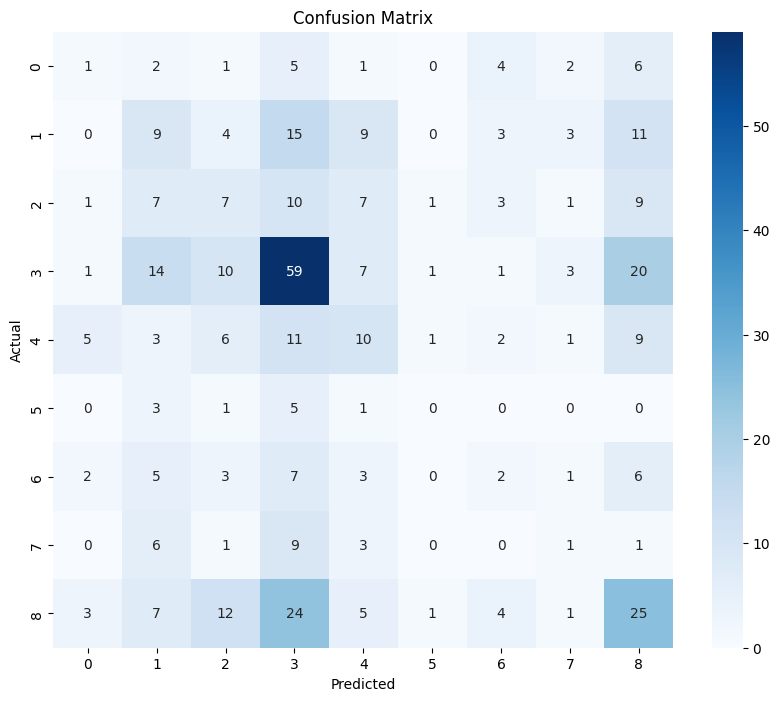

In [16]:

y_pred = model.predict(X_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)
print("Classification Report:\n")
print(classification_report(y_test_labels, y_pred_labels, digits=3))
print("Macro F1-score:", f1_score(y_test, y_pred, average='macro'))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)  # use model.classes_
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


In [20]:
import os
import socket
import tempfile
import subprocess
import numpy as np
import requests
import librosa
import matplotlib.pyplot as plt

def is_url(s: str) -> bool:
    return isinstance(s, str) and s.startswith(("http://", "https://"))

def download_video(url, save_path, timeout=30):
    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept": "*/*",
        "Connection": "keep-alive",
    }
    try:
        resp = requests.get(url, stream=True, headers=headers, timeout=timeout)
        resp.raise_for_status()
        with open(save_path, "wb") as f:
            for chunk in resp.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
    except requests.exceptions.RequestException as e:
        # Common in Internet-off notebooks: DNS NameResolutionError or MaxRetryError
        msg = (
            f"Download failed: {e}\n\n"
            "Tip: If you are in a hosted notebook, enable Internet in notebook Settings, "
            "or provide a local file path instead of a URL."
        )
        raise RuntimeError(msg) from e

def extract_audio_from_video(video_path, audio_path):
    ffmpeg_path = r"C:\ffmpeg-master-latest-win64-gpl-shared\ffmpeg-master-latest-win64-gpl-shared\bin\ffmpeg.exe"
    cmd = [
        ffmpeg_path,
        "-y",
        "-i", video_path,
        "-vn",
        "-acodec", "pcm_s16le",
        "-ar", "22050",   # keep consistent with training
        "-ac", "1",
        audio_path,
    ]
    subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)

def predict_from_mp4_url(source, scaler, model):
    """
    source: URL (http/https) OR local path to an MP4 file.
    """
    with tempfile.TemporaryDirectory() as tmpdir:
        # Determine video source
        if is_url(source):
            video_path = os.path.join(tmpdir, "video.mp4")
            print("Downloading the video...")
            download_video(source, video_path)
        else:
            if not os.path.exists(source):
                raise FileNotFoundError(f"Local video not found: {source}")
            video_path = source

        audio_path = os.path.join(tmpdir, "audio.wav")

        print("Extracting audio...")
        extract_audio_from_video(video_path, audio_path)

        print("Extracting features...")
        features = extract_mfcc(audio_path)  # must return 1D feature vector

        print("Scaling...")
        features_scaled = scaler.transform([features])  # 2D

        print("Predicting...")
        proba = model.predict_proba(features_scaled)[0]
        classes = model.classes_

        print("Plotting...")
        idx = np.argsort(proba)
        plt.figure(figsize=(8, len(classes) * 0.5))
        plt.barh(np.array(classes)[idx], proba[idx], color="skyblue")
        plt.xlabel("Probability")
        plt.title("Class Prediction Probabilities")
        plt.xlim(0, 1)
        for i, v in enumerate(proba[idx]):
            plt.text(v + 0.01, i, f"{v:.2f}", va="center")
        plt.tight_layout()
        plt.show()

        # Return prediction too, in case you want to use it programmatically
        return classes[np.argmax(proba)], dict(zip(classes, proba))


Extracting audio...
Extracting features...
Scaling...
Predicting...
Plotting...


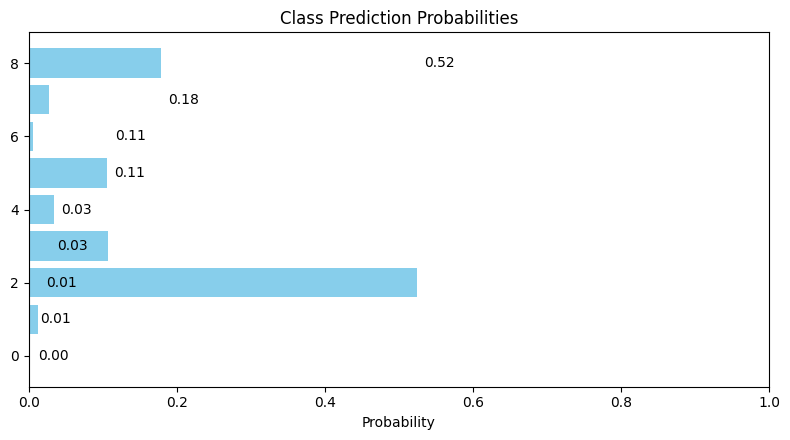

(np.int64(2),
 {np.int64(0): np.float32(0.0022856214),
  np.int64(1): np.float32(0.013314168),
  np.int64(2): np.float32(0.5247255),
  np.int64(3): np.float32(0.10735289),
  np.int64(4): np.float32(0.03445892),
  np.int64(5): np.float32(0.10574537),
  np.int64(6): np.float32(0.005535484),
  np.int64(7): np.float32(0.028204735),
  np.int64(8): np.float32(0.1783773)})

In [21]:
predict_from_mp4_url(r"E:\445 project\speech_recognization_systems-group-6\fahim.mp4", scaler, model)
